In [1]:
import numpy as np

data = np.array([
 [34.2, 220.1, 1.20], # time step 0
 [35.8, 219.5, 1.35], # time step 1
 [38.1, 221.0, 1.50], # time step 2
 [40.3, 218.8, 1.68], # time step 3
 [39.7, 220.5, 1.60], # time step 4
])

data

array([[ 34.2 , 220.1 ,   1.2 ],
       [ 35.8 , 219.5 ,   1.35],
       [ 38.1 , 221.  ,   1.5 ],
       [ 40.3 , 218.8 ,   1.68],
       [ 39.7 , 220.5 ,   1.6 ]])

In [2]:
print(data.shape)

(5, 3)


In [6]:
print(data[:, 0])
print(data[1:3, :])

[34.2 35.8 38.1 40.3 39.7]
[[ 35.8  219.5    1.35]
 [ 38.1  221.     1.5 ]]


In [7]:
print(data.mean(axis=0))

[ 37.62  219.98    1.466]


In [12]:
import pandas as pd
import numpy as np
# ─── CREATING A DATAFRAME FROM A DICTIONARY ──────────────────────────
# Keys become column names; values are lists of column data
df = pd.DataFrame({
 "timestamp": pd.date_range("2025-06-01 09:00", periods=6, freq="5min"),
 "temperature": [34.2, 35.8, 38.1, 40.3, 39.7, 36.5],
 "voltage": [220.1, 219.5, 221.0, 218.8, 220.5, 220.0],
 "current": [1.20, 1.35, 1.50, 1.68, 1.60, 1.40],
 "status": ["ok", "ok", "warn", "crit", "warn", "ok"],
})

df

,timestamp,temperature,voltage,current,status
0,2025-06-01 09:00:00,34.2,220.1,1.20,ok
1,2025-06-01 09:05:00,35.8,219.5,1.35,ok
2,2025-06-01 09:10:00,38.1,221.0,1.50,warn
3,2025-06-01 09:15:00,40.3,218.8,1.68,crit
4,2025-06-01 09:20:00,39.7,220.5,1.60,warn
5,2025-06-01 09:25:00,36.5,220.0,1.40,ok


In [13]:
df.set_index("timestamp", inplace=True)

In [20]:
df.replace("timestamp", "time")
df

,temperature,voltage,current,status
timestamp,,,,
2025-06-01 09:00:00,34.2,220.1,1.20,ok
2025-06-01 09:05:00,35.8,219.5,1.35,ok
2025-06-01 09:10:00,38.1,221.0,1.50,warn
2025-06-01 09:15:00,40.3,218.8,1.68,crit
2025-06-01 09:20:00,39.7,220.5,1.60,warn
2025-06-01 09:25:00,36.5,220.0,1.40,ok


In [21]:
print(df.describe())

       temperature     voltage   current
count     6.000000    6.000000  6.000000
mean     37.433333  219.983333  1.455000
std       2.357682    0.767898  0.174786
min      34.200000  218.800000  1.200000
25%      35.975000  219.625000  1.362500
50%      37.300000  220.050000  1.450000
75%      39.300000  220.400000  1.575000
max      40.300000  221.000000  1.680000


In [22]:
print(df.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 6 entries, 2025-06-01 09:00:00 to 2025-06-01 09:25:00
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  6 non-null      float64
 1   voltage      6 non-null      float64
 2   current      6 non-null      float64
 3   status       6 non-null      str    
dtypes: float64(3), str(1)
memory usage: 240.0 bytes
None


In [23]:
temps = df["temperature"]

In [26]:
temps

timestamp
2025-06-01 09:00:00    34.2
2025-06-01 09:05:00    35.8
2025-06-01 09:10:00    38.1
2025-06-01 09:15:00    40.3
2025-06-01 09:20:00    39.7
2025-06-01 09:25:00    36.5
Name: temperature, dtype: float64

In [37]:
df.loc[df.index[3], "current"]=None

df

,temperature,voltage,current,status
timestamp,,,,
2025-06-01 09:00:00,34.2,220.1,1.20,ok
2025-06-01 09:05:00,35.8,219.5,1.35,ok
2025-06-01 09:10:00,38.1,221.0,1.50,warn
2025-06-01 09:15:00,40.3,218.8,NaN,crit
2025-06-01 09:20:00,39.7,220.5,1.60,warn
2025-06-01 09:25:00,36.5,220.0,1.40,ok


In [39]:
df.isnull().sum()

temperature    0
voltage        0
current        1
status         0
dtype: int64

In [43]:
df["current"] = df["current"].fillna(df["current"].mean())
df

,temperature,voltage,current,status
timestamp,,,,
2025-06-01 09:00:00,34.2,220.1,1.20,ok
2025-06-01 09:05:00,35.8,219.5,1.35,ok
2025-06-01 09:10:00,38.1,221.0,1.50,warn
2025-06-01 09:15:00,40.3,218.8,1.41,crit
2025-06-01 09:20:00,39.7,220.5,1.60,warn
2025-06-01 09:25:00,36.5,220.0,1.40,ok


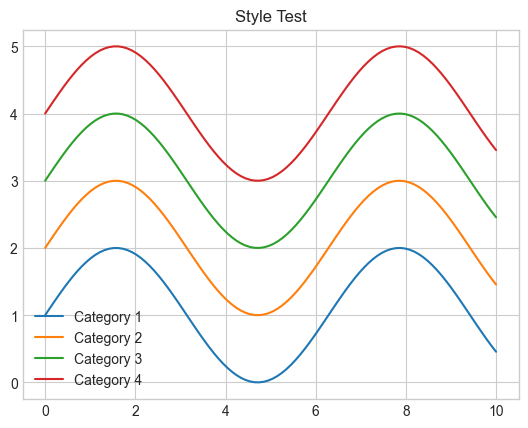

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# GLOBAL STYLE:

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("tab10")

x=np.linspace(0, 10, 100)

for i in range(1, 5):
    plt.plot(x, np.sin(x)+i, label=f"Category {i}")
plt.title("Style Test")
plt.legend()
plt.show()


In [10]:
np.random.seed(0)
n=200

t=np.linspace(0, 24, n)

# temperature : sinusoidal daily cycle + Gaussian noise
temp=35+6*np.sin(2*np.pi*t/24) + np.random.normal(0, 0.05,n)


In [13]:
num=[23, 24, 23.4, 22.5, 21.5]
result=[]
for n in num:
    result.append(n*1.8+32)
print(result)
    


[73.4, 75.2, 74.12, 72.5, 70.7]


In [19]:
import numpy as np
result=[]
new_num=np.array([23, 24, 23.4, 22.5, 21.5])
new_num

result=new_num*1.8+32

result


array([73.4 , 75.2 , 74.12, 72.5 , 70.7 ])

### � Vectorisation — the Key Concept

n a Python loop, you process one number at a time. In NumPy, you apply an operation to the
entire array at once — this is called vectorisation.
Example: converting 100,000 Celsius readings to Fahrenheit.
Python loop: for val in readings: result.append(val * 1.8 + 32) — slow, one at a time.
NumPy: result = readings_array * 1.8 + 32 — one line, operates on all 100,000 simultaneously.
This is not a shortcut — it is a fundamentally different computational model.

In [21]:
temps = np.array([34.2, 35.1, 36.5, 37.8, 39.2, 41.0, 38.5, 36.0])
temps

array([34.2, 35.1, 36.5, 37.8, 39.2, 41. , 38.5, 36. ])

In [30]:
# inititial_weights=[0,0]
zeros=np.zeros(1000)
ones=np.ones(1000)
# rnge=np.range(start, stop, step)
rnge=np.arange(0, 1000, 2)

# linsp=np.linspace(start, stop, count)
linsp=np.linspace(0, 1, 1000)

linsp

array([0.        , 0.001001  , 0.002002  , 0.003003  , 0.004004  ,
       0.00500501, 0.00600601, 0.00700701, 0.00800801, 0.00900901,
       0.01001001, 0.01101101, 0.01201201, 0.01301301, 0.01401401,
       0.01501502, 0.01601602, 0.01701702, 0.01801802, 0.01901902,
       0.02002002, 0.02102102, 0.02202202, 0.02302302, 0.02402402,
       0.02502503, 0.02602603, 0.02702703, 0.02802803, 0.02902903,
       0.03003003, 0.03103103, 0.03203203, 0.03303303, 0.03403403,
       0.03503504, 0.03603604, 0.03703704, 0.03803804, 0.03903904,
       0.04004004, 0.04104104, 0.04204204, 0.04304304, 0.04404404,
       0.04504505, 0.04604605, 0.04704705, 0.04804805, 0.04904905,
       0.05005005, 0.05105105, 0.05205205, 0.05305305, 0.05405405,
       0.05505506, 0.05605606, 0.05705706, 0.05805806, 0.05905906,
       0.06006006, 0.06106106, 0.06206206, 0.06306306, 0.06406406,
       0.06506507, 0.06606607, 0.06706707, 0.06806807, 0.06906907,
       0.07007007, 0.07107107, 0.07207207, 0.07307307, 0.07407

In [35]:
np.random.seed(42)

noise=np.random.normal(0, 0.5, 100)
uniform=np.random.uniform(low=30, high=45, size=50)
noise

array([ 0.24835708, -0.06913215,  0.32384427,  0.76151493, -0.11707669,
       -0.11706848,  0.78960641,  0.38371736, -0.23473719,  0.27128002,
       -0.23170885, -0.23286488,  0.12098114, -0.95664012, -0.86245892,
       -0.28114376, -0.50641556,  0.15712367, -0.45401204, -0.70615185,
        0.73282438, -0.11288815,  0.0337641 , -0.71237409, -0.27219136,
        0.05546129, -0.57549679,  0.18784901, -0.30031934, -0.14584687,
       -0.30085331,  0.92613909, -0.00674861, -0.52885546,  0.41127246,
       -0.61042182,  0.1044318 , -0.97983506, -0.66409302,  0.09843062,
        0.36923329,  0.08568414, -0.05782414, -0.15055185, -0.739261  ,
       -0.3599221 , -0.23031939,  0.52856111,  0.17180914, -0.88152008,
        0.16204198, -0.19254114, -0.338461  ,  0.30583814,  0.51549976,
        0.46564006, -0.41960876, -0.15460619,  0.16563172,  0.48777256,
       -0.23958712, -0.09282949, -0.55316749, -0.59810331,  0.40626291,
        0.67812001, -0.03600506,  0.50176645,  0.18081801, -0.32

In [40]:
# ─── ARRAY PROPERTIES ───────────────────
print(temps.shape)
print(temps.dtype)

(8,)
float64


In [49]:
lolo=np.array([[1,3,5], [1,4,5]])
lolo
lolo.shape

(2, 3)

In [51]:
# Min-max normalisation on the entire array — one line
normalised=(temps-temps.min()/temps.max()-temps.min())
normalised

array([-0.83414634,  0.06585366,  1.46585366,  2.76585366,  4.16585366,
        5.96585366,  3.46585366,  0.96585366])

In [57]:
data=np.array([
  [34.2, 220.1, 1.20], # time step 0
 [35.8, 219.5, 1.35], # time step 1
 [38.1, 221.0, 1.50], # time step 2
 [40.3, 218.8, 1.68], # time step 3
 [39.7, 220.5, 1.60,], # time step 4
])

In [54]:
data

array([[ 34.2 , 220.1 ,   1.2 ],
       [ 35.8 , 219.5 ,   1.35],
       [ 38.1 , 221.  ,   1.5 ],
       [ 40.3 , 218.8 ,   1.68],
       [ 39.7 , 220.5 ,   1.6 ]])

In [59]:
print(data.shape)

(5, 3)


In [62]:
# Indexing in 2d

print(data[0, 0])

34.2


In [64]:
# Getting a range

print(data[:, 0])

[34.2 35.8 38.1 40.3 39.7]


In [66]:
print(data[1:3, :])

[[ 35.8  219.5    1.35]
 [ 38.1  221.     1.5 ]]


In [68]:
print(data[:, 1:])

[[220.1    1.2 ]
 [219.5    1.35]
 [221.     1.5 ]
 [218.8    1.68]
 [220.5    1.6 ]]


In [71]:
# Column-wise statistics (axis=0 means 'along rows', result has shape (3,))
col_means = data.mean(axis=0)
col_means

array([ 37.62 , 219.98 ,   1.466])

In [73]:
row_means = data.mean(axis=1)
row_means

array([85.16666667, 85.55      , 86.86666667, 86.92666667, 87.26666667])

In [80]:
# Day 2 — Pandas: Your Engineering Data Wo

import pandas as pd
import numpy as np

# CREATE 

df = pd.DataFrame({
 "timestamp": pd.date_range("2025-06-01 09:00", periods=6, freq="5min"),
 "temperature": [34.2, 35.8, 38.1, 40.3, 39.7, 36.5],
 "voltage": [220.1, 219.5, 221.0, 218.8, 220.5, 220.0],
 "current": [1.20, 1.35, 1.50, 1.68, 1.60, 1.40],
 "status": ["ok", "ok", "warn", "crit", "warn", "ok"],
})

df

,timestamp,temperature,voltage,current,status
0,2025-06-01 09:00:00,34.2,220.1,1.20,ok
1,2025-06-01 09:05:00,35.8,219.5,1.35,ok
2,2025-06-01 09:10:00,38.1,221.0,1.50,warn
3,2025-06-01 09:15:00,40.3,218.8,1.68,crit
4,2025-06-01 09:20:00,39.7,220.5,1.60,warn
5,2025-06-01 09:25:00,36.5,220.0,1.40,ok


In [77]:
print(df.shape)

(6, 5)


In [79]:
print(df.dtypes)

timestamp      datetime64[us]
temperature           float64
voltage               float64
current               float64
status                    str
dtype: object


In [85]:
print(df.head(5))
# print(df.tail(3))

            timestamp  temperature  voltage  current status
0 2025-06-01 09:00:00         34.2    220.1     1.20     ok
1 2025-06-01 09:05:00         35.8    219.5     1.35     ok
2 2025-06-01 09:10:00         38.1    221.0     1.50   warn
3 2025-06-01 09:15:00         40.3    218.8     1.68   crit
4 2025-06-01 09:20:00         39.7    220.5     1.60   warn


In [88]:
df.describe()

,timestamp,temperature,voltage,current
count,6,6.000000,6.000000,6.000000
mean,2025-06-01 09:12:30,37.433333,219.983333,1.455000
min,2025-06-01 09:00:00,34.200000,218.800000,1.200000
25%,2025-06-01 09:06:15,35.975000,219.625000,1.362500
50%,2025-06-01 09:12:30,37.300000,220.050000,1.450000
75%,2025-06-01 09:18:45,39.300000,220.400000,1.575000
max,2025-06-01 09:25:00,40.300000,221.000000,1.680000
std,NaN,2.357682,0.767898,0.174786


In [90]:
print(df["temperature"])

0    34.2
1    35.8
2    38.1
3    40.3
4    39.7
5    36.5
Name: temperature, dtype: float64


In [93]:
readings = df[["temperature", "voltage", "current"]]
readings

,temperature,voltage,current
0,34.2,220.1,1.20
1,35.8,219.5,1.35
2,38.1,221.0,1.50
3,40.3,218.8,1.68
4,39.7,220.5,1.60
5,36.5,220.0,1.40


In [98]:
warnings = df[df["status"] == "ok"]
warnings

,timestamp,temperature,voltage,current,status
0,2025-06-01 09:00:00,34.2,220.1,1.20,ok
1,2025-06-01 09:05:00,35.8,219.5,1.35,ok
5,2025-06-01 09:25:00,36.5,220.0,1.40,ok


In [100]:
hot_rows = df[df["temperature"] > 38.0]
hot_rows

,timestamp,temperature,voltage,current,status
2,2025-06-01 09:10:00,38.1,221.0,1.50,warn
3,2025-06-01 09:15:00,40.3,218.8,1.68,crit
4,2025-06-01 09:20:00,39.7,220.5,1.60,warn


In [103]:
danger = df[(df["temperature"] > 39) & (df["voltage"] < 220)]
danger

,timestamp,temperature,voltage,current,status
3,2025-06-01 09:15:00,40.3,218.8,1.68,crit


In [107]:
df["power_w"]=df["voltage"] * df["current"]
df["temp_f"]=df["temperature"] * 1.8+32
df["high_risk"]=df["temperature"]>39.0

df

,timestamp,temperature,voltage,current,status,power_w,temp_f,high_risk
0,2025-06-01 09:00:00,34.2,220.1,1.20,ok,264.120,93.56,False
1,2025-06-01 09:05:00,35.8,219.5,1.35,ok,296.325,96.44,False
2,2025-06-01 09:10:00,38.1,221.0,1.50,warn,331.500,100.58,False
3,2025-06-01 09:15:00,40.3,218.8,1.68,crit,367.584,104.54,True
4,2025-06-01 09:20:00,39.7,220.5,1.60,warn,352.800,103.46,True
5,2025-06-01 09:25:00,36.5,220.0,1.40,ok,308.000,97.70,False


In [119]:
# ─── HANDLING MISSING DATA ───────────────────────────────────────────
# Introduce a missing value for demonstration

# df.loc[df.index[2], "current"]=None
for i in range(1, 6):
    if i%2!=0:
        df.loc[df.index[i], "current"]=None
    

# df["current"]=df["current"].fillna(df["current"].mean())
df.dropna(inplace=True)


IndexError: index 3 is out of bounds for axis 0 with size 3

In [120]:
print(df.groupby("status")["temperature"].describe())


        count  mean       std   min   25%   50%   75%   max
status                                                     
ok        1.0  34.2       NaN  34.2  34.2  34.2  34.2  34.2
warn      2.0  38.9  1.131371  38.1  38.5  38.9  39.3  39.7


In [1]:
df.to_csv("processed_sensor_log.csv")

NameError: name 'df' is not defined

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


In [5]:
# ─── GLOBAL STYLE ────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid") # clean white background
sns.set_palette("tab10") # distinct colour palette

In [7]:
# ─── GENERATE REALISTIC SENSOR DATA ─────────────────────────────────
np.random.seed(0)
n = 200
t = np.linspace(0, 24, n) # 24 hours
# Temperature: sinusoidal daily cycle + Gaussian noise
temp = 35 + 6 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 0.8, n)
# Current: correlated with temperature (motor draws more when hot)
current = 1.2 + 0.015 * (temp - 35) + np.random.normal(0, 0.05, n)
# Voltage: slight negative correlation with load
voltage = 221 - 0.8 * (current - 1.2) + np.random.normal(0, 0.5, n)

In [9]:
df = pd.DataFrame({"time_h": t, "temp_C": temp,
 "current_A": current, "voltage_V": voltage})
df["power_W"] = df["voltage_V"] * df["current_A"]
df

,time_h,temp_C,current_A,voltage_V,power_W
0,0.000000,36.411242,1.202710,220.698505,265.436197
1,0.120603,35.509537,1.195674,220.445512,263.580989
2,0.241206,36.161624,1.272407,221.325406,281.616071
3,0.361809,37.360193,1.268166,221.123614,280.421468
4,0.482412,37.249805,1.265754,220.063128,278.545706
...,...,...,...,...,...
195,23.517588,34.107005,1.148530,221.230793,254.090305
196,23.638191,35.049954,1.243646,220.730067,274.509955
197,23.758794,35.280170,1.261258,220.842628,278.539451
198,23.879397,36.541177,1.296447,220.457764,285.811719


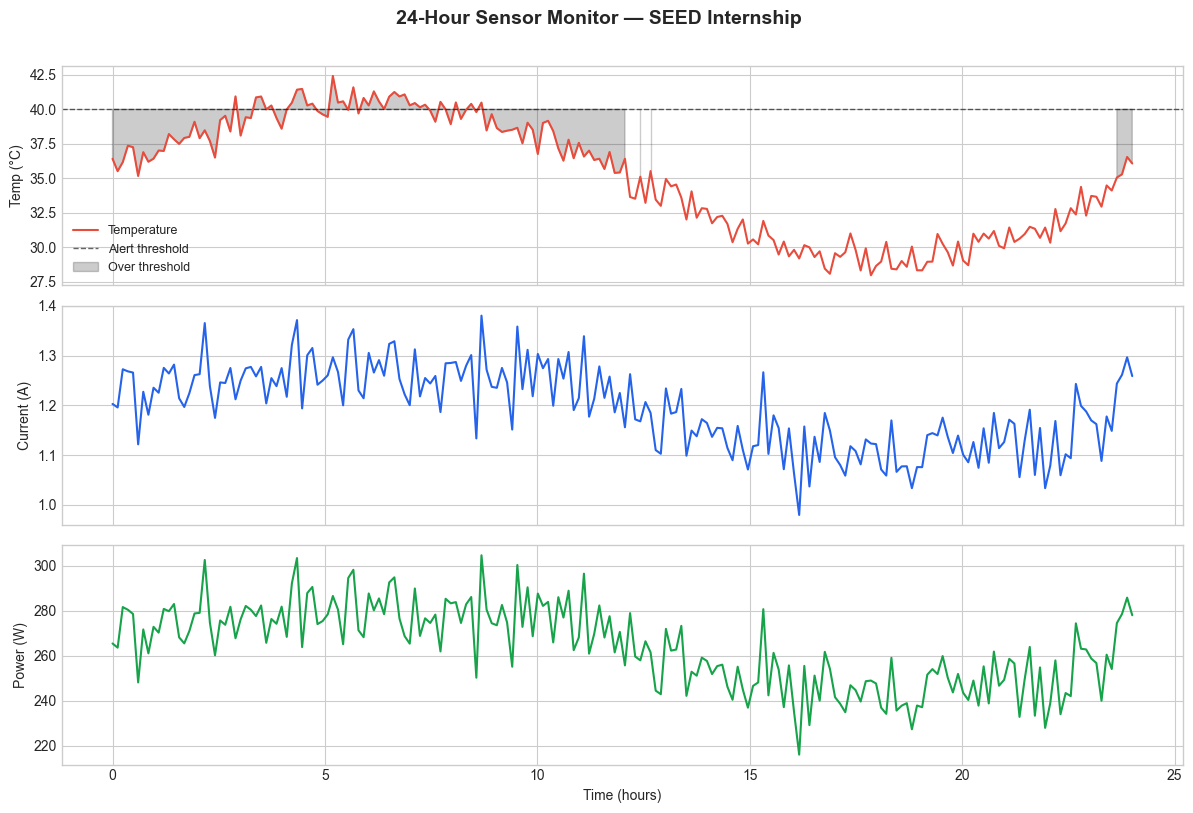

In [19]:
# ══════════════════════════════════════════════════════════════
# FIGURE 1: Multi-panel time-series (the most useful daily plot)
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle("24-Hour Sensor Monitor — SEED Internship",
 fontsize=14, fontweight="bold", y=1.01)
axes[0].plot(df["time_h"], df["temp_C"],
 color="#E74C3C", linewidth=1.5, label="Temperature")

axes[0].axhline(y=40, color="black", linestyle="--", alpha=0.6,
 linewidth=1, label="Alert threshold")
axes[0].fill_between(df["time_h"], df["temp_C"], 40,
 where=(df["temp_C"] > 35),
color="black", alpha=0.2, label="Over threshold")
axes[0].set_ylabel("Temp (°C)", fontsize=10)
axes[0].legend(fontsize=9)
axes[1].plot(df["time_h"], df["current_A"],═


In [20]:

plt.show()

In [2]:
# ══════════════════════════════════════════════════════════════
# FIGURE 2: Distribution plots — understanding your data's shap


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Feature Distributions", fontsize=13, fontweight="bold")


     

NameError: name 'plt' is not defined

In [4]:
# The scikit-learn API Pattern — memorise this structure:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [7]:
# Randomly generated data — house size (sqft) predicting price ($1000s)
np.random.seed(42)
n = 100

house_size = np.random.randint(800, 3500, n)
bedrooms   = np.random.randint(1, 6, n)
age        = np.random.randint(1, 40, n)

# Target: price has a real relationship + some noise
price = (0.12 * house_size) + (15 * bedrooms) - (1.5 * age) + np.random.normal(0, 20, n)

X = np.column_stack([house_size, bedrooms, age])
y = price


In [9]:
X

array([[1660,    5,   17],
       [2094,    2,   38],
       [1930,    2,   24],
       [1895,    1,    5],
       [2438,    4,   34],
       [2969,    1,    6],
       [1266,    4,   22],
       [2038,    2,   11],
       [1130,    1,   16],
       [2282,    5,   33],
       [2935,    3,    9],
       [ 930,    4,    6],
       [2485,    3,   16],
       [1569,    3,   29],
       [3191,    1,    3],
       [2315,    3,   20],
       [3233,    5,   36],
       [2015,    3,   19],
       [1755,    1,   26],
       [3124,    5,    3],
       [1984,    2,   19],
       [1259,    3,   20],
       [ 821,    1,   32],
       [3100,    2,    7],
       [1547,    2,   33],
       [1274,    4,   39],
       [1882,    5,   18],
       [3358,    3,    1],
       [2847,    1,   11],
       [1775,    4,   28],
       [2606,    5,   25],
       [ 989,    4,   23],
       [1362,    5,   31],
       [2699,    5,   30],
       [2067,    3,   35],
       [2328,    5,    7],
       [1446,    4,   16],
 

In [10]:
# Step 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Step 4
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5
y_pred = model.predict(X_test)

# Step 6
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f"MSE: {mse:.3f}   R²: {r2:.3f}")

MSE: 322.240   R²: 0.974


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def f(x):
    return x**2
f(2)

4

In [5]:
def f_grad(x):
    return 2*x;


In [8]:
x_vals=np.linspace(-3, 3, 300)
# x_vals
y=f(x_vals);
y

array([9.00000000e+00, 8.88000134e+00, 8.76080804e+00, 8.64242011e+00,
       8.52483753e+00, 8.40806031e+00, 8.29208846e+00, 8.17692196e+00,
       8.06256082e+00, 7.94900504e+00, 7.83625463e+00, 7.72430957e+00,
       7.61316988e+00, 7.50283554e+00, 7.39330656e+00, 7.28458295e+00,
       7.17666469e+00, 7.06955179e+00, 6.96324426e+00, 6.85774208e+00,
       6.75304527e+00, 6.64915381e+00, 6.54606772e+00, 6.44378698e+00,
       6.34231161e+00, 6.24164159e+00, 6.14177694e+00, 6.04271764e+00,
       5.94446371e+00, 5.84701513e+00, 5.75037192e+00, 5.65453407e+00,
       5.55950157e+00, 5.46527444e+00, 5.37185266e+00, 5.27923625e+00,
       5.18742520e+00, 5.09641950e+00, 5.00621917e+00, 4.91682420e+00,
       4.82823458e+00, 4.74045033e+00, 4.65347144e+00, 4.56729790e+00,
       4.48192973e+00, 4.39736692e+00, 4.31360947e+00, 4.23065738e+00,
       4.14851064e+00, 4.06716927e+00, 3.98663326e+00, 3.90690261e+00,
       3.82797732e+00, 3.74985738e+00, 3.67254281e+00, 3.59603360e+00,
      

## Plotting a graph 
density==True in histplot means, squash the values between 0 and 1

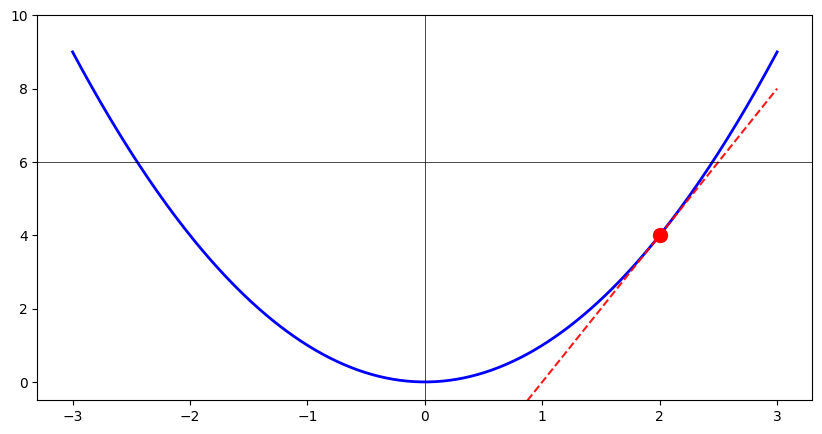

In [26]:
plt.figure(figsize=(10,5))
plt.plot(x_vals, y, color="blue", linewidth=2, label="Loss: f(x)=x²")
x0=2.0;
grad=f_grad(x0) 
tangent=grad * (x_vals-x0) + f(x0) # it gives us the tangent line
plt.plot(x_vals, tangent, color="red", linestyle="--", alpha=0.9, label="Tangent curve")
plt.scatter([x0], [f(x0)], s=100, color="red", zorder=5)
plt.ylim(-0.5, 10)
plt.axhline(6, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)

In [12]:
# at x0=2, our slope is 4